In [46]:
import heapq
import math
import random
import time
import json
import os
import numpy as np
from collections import deque
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.path as mpath
from matplotlib.transforms import Affine2D
from IPython.display import clear_output, display, Audio

DELAY_BETWEEN_FRAMES = 0.1

In [47]:
# ==========================================
# MODULE: OFFLINE LAYOUT STORAGE
# ==========================================
class LayoutManager:
    def __init__(self, filename="floor_plan_offline.json"):
        self.filename = filename

    def save_layout(self, grid, size):
        """Saves static map elements (Walls, Windows, Exits) to JSON."""
        layout_data = {
            "size": size,
            "walls": [],
            "windows": [],
            "exits": []
        }
        for pos, node in grid.items():
            if node.type == 'WALL':
                layout_data["walls"].append(pos)
            elif node.type == 'WINDOW':
                layout_data["windows"].append(pos)
            # Detect Exits (Goals)
            if node.x == 0 or node.x == size-1 or node.y == 0 or node.y == size-1:
                if node.type == 'EMPTY': 
                     layout_data["exits"].append(pos)

        with open(self.filename, 'w') as f:
            json.dump(layout_data, f)
        # print(f"✅ [SYSTEM] Layout saved to {self.filename}")

    def load_layout(self):
        """Returns: size, walls_set, windows_set, exits_set (or None)"""
        if not os.path.exists(self.filename):
            return None

        with open(self.filename, 'r') as f:
            data = json.load(f)
        
        walls = set(tuple(x) for x in data["walls"])
        windows = set(tuple(x) for x in data["windows"])
        exits = set(tuple(x) for x in data["exits"])
        print(f"✅ [SYSTEM] Loaded offline layout: {data['size']}x{data['size']}")
        return data["size"], walls, windows, exits

# ==========================================
# MODULE: SENSORY FEEDBACK (HAPTICS/AUDIO)
# ==========================================
class NavigationFeedback:
    def __init__(self):
        self.last_instruction = None

    def trigger(self, instruction):
        """Simulates Haptic vibration and Audio cues."""
        if instruction == self.last_instruction:
            return 
        self.last_instruction = instruction
        
        # In a real app, these print statements are API calls to the phone's vibrator
        if instruction == "TURN LEFT":
            return "📳 VIBRATE: [Short-Short] (Left)"
        elif instruction == "TURN RIGHT":
            return "📳 VIBRATE: [Long] (Right)"
        elif instruction == "TURN BACK":
            return "📳 VIBRATE: [Continuous] (Wrong Way)"
        elif instruction == "STOP!":
            return "🚨 HAPTIC: [INTENSE PULSE] (DANGER)"
        return ""

In [48]:
# ==========================================
# MODULE: PDR (PEDESTRIAN DEAD RECKONING)
# ==========================================
class PDRSystem:
    def __init__(self, start_x, start_y, step_len=1.0):
        # Estimated Position (The "Phone's" belief)
        self.est_x = start_x
        self.est_y = start_y
        self.heading = 0.0 # 0 = East
        self.step_length = step_len
        
        # Sensor Noise Parameters
        self.gyro_bias = 0.02 
        self.accel_noise = 0.1

    def simulate_hardware_reading(self, true_curr, true_next):
        """
        Generates noisy sensor data based on actual movement.
        (Simulates the hardware layer)
        """
        dx = true_next.x - true_curr.x
        dy = true_next.y - true_curr.y
        
        # Ideal Heading
        target_angle = math.atan2(dy, dx)
        
        # Simulate Gyro: Change in angle + Noise
        gyro_z = (target_angle - self.heading) + random.gauss(0, self.gyro_bias)
        
        # Simulate Accel: Spike if moving, Gravity (0.98) if still
        is_moving = (dx != 0 or dy != 0)
        accel_mag = (1.5 if is_moving else 0.98) + random.gauss(0, self.accel_noise)
        
        return accel_mag, gyro_z

    def update_estimate(self, accel, gyro_z):
        """
        The Algorithm: Integrates raw sensor data to get position.
        """
        # 1. Integrate Gyro to get Heading
        self.heading += gyro_z
        
        # 2. Threshold Accel to detect Step
        if accel > 1.2: # Step Threshold
            # Move in direction of heading
            self.est_x += self.step_length * math.cos(self.heading)
            self.est_y += self.step_length * math.sin(self.heading)
            
        return self.est_x, self.est_y

In [49]:
# ==========================================
# CORE ALGORITHMS (D* LITE + SIMULATION)
# ==========================================

def approx(a, b, tol=1e-5):
    if a == float('inf') and b == float('inf'): return True
    if a == float('inf') or b == float('inf'): return False
    return abs(a - b) < tol

class Key:
    def __init__(self, k1, k2):
        self.k1, self.k2 = k1, k2
    def __lt__(self, other):
        if approx(self.k1, other.k1): return self.k2 < other.k2
        return self.k1 < other.k1
    def __repr__(self): return f"({self.k1:.2f}, {self.k2:.2f})"

class Node:
    def __init__(self, x, y):
        self.x, self.y = x, y
        self.pos = (x, y)
        self.g = float('inf')
        self.rhs = float('inf')
        self.neighbors = []
        
        self.type = 'EMPTY' 
        self.crowd_density = 0 
        self.has_sensor = False
        
        self.perceived_type = 'EMPTY'
        self.perceived_crowd = 0
        self.fire_risk = 0.0
        self.visited = False 
        
    def __lt__(self, other): return self.pos < other.pos
    def __repr__(self): return f"N{self.pos}"

class DStarLite:
    def __init__(self, start, goals, windows, nodes_dict):
        self.start = start 
        self.goals = goals 
        self.windows = windows 
        self.nodes = nodes_dict
        self.km = 0.0
        self.queue = []
        self.in_queue = {} 
        self.fire_near_main_exits = False
        self.prev_fire_state = False

    def h(self, n):
        return abs(n.x - self.start.x) + abs(n.y - self.start.y) 

    def calc_key(self, u):
        m = min(u.g, u.rhs)
        return Key(m + self.h(u) + self.km, m)

    def c(self, u, v):
        if u.perceived_type in ['FIRE', 'WALL', 'RUBBLE'] or v.perceived_type in ['FIRE', 'WALL', 'RUBBLE']: return float('inf')
        
        cost = 1.0
        if v.fire_risk > 0: cost += v.fire_risk
        
        near_fire = any(n.perceived_type == 'FIRE' for n in v.neighbors)
        if near_fire: cost += 100.0 
        if v.perceived_type == 'SMOKE': cost += 20.0
        
        if v in self.windows: 
            cost += 1.0 if self.fire_near_main_exits else 200.0 

        if v.perceived_type == 'CROWD':
            cost += 10.0 * (v.perceived_crowd ** 2) 
            active_exits = [n for n in (self.goals + self.windows) if n.perceived_type != 'RUBBLE']
            if active_exits:
                dist_to_exit = min([math.hypot(v.x - g.x, v.y - g.y) for g in active_exits])
                if dist_to_exit < 2: cost -= 15.0 
        return cost

    def update_vertex(self, u):
        key = self.calc_key(u)
        if not approx(u.g, u.rhs):
            heapq.heappush(self.queue, (key, u))
            self.in_queue[u] = key
        elif u in self.in_queue:
            del self.in_queue[u]

    def compute_shortest_path(self):
        while self.queue:
            k_old, u = self.queue[0]
            k_start = self.calc_key(self.start)
            if u not in self.in_queue or (self.in_queue[u].k1 != k_old.k1 or self.in_queue[u].k2 != k_old.k2):
                heapq.heappop(self.queue); continue
            if k_old < k_start or self.start.rhs > self.start.g:
                heapq.heappop(self.queue)
                if u in self.in_queue: del self.in_queue[u]
                k_new = self.calc_key(u)
                if k_old < k_new:
                    heapq.heappush(self.queue, (k_new, u)); self.in_queue[u] = k_new
                elif u.g > u.rhs:
                    u.g = u.rhs
                    for s in u.neighbors:
                        if s.perceived_type != 'RUBBLE': s.rhs = min(s.rhs, self.c(s, u) + u.g)
                        self.update_vertex(s)
                else:
                    g_old = u.g; u.g = float('inf')
                    for s in u.neighbors + [u]:
                        if approx(s.rhs, self.c(s, u) + g_old):
                            if s.perceived_type != 'RUBBLE' and s not in self.goals and s not in self.windows:
                                s.rhs = float('inf')
                                for sp in s.neighbors: s.rhs = min(s.rhs, self.c(s, sp) + sp.g)
                            if s.perceived_type == 'RUBBLE': s.rhs = float('inf')
                        self.update_vertex(s)
            else: break

    def initialize(self):
        self.km = 0; self.queue = []; self.in_queue = {}
        for n in self.nodes.values(): n.g = float('inf'); n.rhs = float('inf')
        targets = [t for t in (self.goals + self.windows) if t.perceived_type != 'RUBBLE']
        for target in targets:
            target.rhs = 100.0 if (target in self.windows and not self.fire_near_main_exits) else 0.0
            key = self.calc_key(target)
            heapq.heappush(self.queue, (key, target)); self.in_queue[target] = key
        self.compute_shortest_path()

    def update_map(self, changed_nodes):
        for u in changed_nodes:
            if u.perceived_type == 'FIRE':
                for g in self.goals:
                    if math.hypot(u.x - g.x, u.y - g.y) < 5.0: self.fire_near_main_exits = True
        
        if self.fire_near_main_exits != self.prev_fire_state:
            self.prev_fire_state = self.fire_near_main_exits
            for w in self.windows:
                self.update_vertex(w)
                for n in w.neighbors:
                    if n.perceived_type != 'RUBBLE':
                        n.rhs = min(n.rhs, self.c(n, w) + w.g)
                        self.update_vertex(n)

        for u in changed_nodes:
            if u.perceived_type in ['RUBBLE', 'WALL', 'FIRE'] and (u in self.goals or u in self.windows):
                u.g = float('inf'); u.rhs = float('inf')
                for s in u.neighbors: self.update_vertex(s)
                self.update_vertex(u); continue

            for s in u.neighbors + [u]:
                if s.perceived_type != 'RUBBLE':
                    if s not in self.goals and s not in self.windows:
                        s.rhs = float('inf')
                        for sp in s.neighbors: s.rhs = min(s.rhs, self.c(s, sp) + sp.g)
                self.update_vertex(s)
        self.compute_shortest_path()

    def move_agent(self):
        if self.start.rhs == float('inf'): return None
        best, min_c = None, float('inf')
        for n in self.start.neighbors:
            edge_cost = self.c(self.start, n)
            if edge_cost == float('inf'): continue
            if edge_cost + n.g < min_c:
                min_c = edge_cost + n.g; best = n
        if best and min_c != float('inf'):
            self.km += self.h(best); self.start = best; return best
        return None

    def get_distance_to_exit(self):
        return self.start.g if self.start.g != float('inf') else 0.0

    def get_next_instruction(self, current_node, next_node):
        if not next_node: return "SEARCHING"
        dx, dy = next_node.x - current_node.x, next_node.y - current_node.y
        if dx == 0 and dy > 0: return "UP"
        if dx == 0 and dy < 0: return "DOWN"
        if dx > 0 and dy == 0: return "RIGHT"
        if dx < 0 and dy == 0: return "LEFT"
        return "WAIT"

class Simulation:
    def __init__(self, size=60, layout_mgr=None):
        self.solver = None
        self.size = size
        self.grid = {}
        self.nodes_list = []
        self.layout_mgr = layout_mgr
        
        # Initialize Grid
        for x in range(size):
            for y in range(size):
                n = Node(x, y)
                self.grid[(x,y)] = n; self.nodes_list.append(n)
        
        # Connect Neighbors
        directions = [(-1, 0), (1, 0), (0, -1), (0, 1)] 
        for n in self.nodes_list:
            for dx, dy in directions:
                nx, ny = n.x+dx, n.y+dy
                if (nx, ny) in self.grid: n.neighbors.append(self.grid[(nx, ny)])

        self.goals = []; self.windows = []
        
        # OFFLINE LAYOUT LOADING
        loaded = False
        if self.layout_mgr:
            data = self.layout_mgr.load_layout()
            if data and data[0] == size:
                _, walls, windows, exits = data
                for pos in walls: self.grid[pos].type = 'WALL'
                for pos in windows: 
                    self.grid[pos].type = 'WINDOW'; self.windows.append(self.grid[pos])
                for pos in exits: 
                    self.grid[pos].type = 'EMPTY'; self.goals.append(self.grid[pos])
                loaded = True
        
        if not loaded:
            self.generate_building_plan()
            if self.layout_mgr: self.layout_mgr.save_layout(self.grid, size)

        # Simulation State
        self.hidden_hazards = set()
        self.sensors = [] 
        self.setup_sensors() 
        
        valid_spawns = [n for n in self.nodes_list if n.type == 'EMPTY' and n not in self.goals and n not in self.windows]
        self.start_node = random.choice(valid_spawns)
        
        self.crowd_agents = [] 
        num_people = int((size * size) * 0.05) 
        for _ in range(num_people):
            n = self.grid[(random.randint(0, size-1), random.randint(0, size-1))]
            if n.type == 'EMPTY' and n != self.start_node and n not in self.goals:
                n.type = 'CROWD'; 
                self.crowd_agents.append({'node': n, 'has_app': random.random() < 0.05})
        
        self.flow_field_crowd = {}; self.flow_field_app = {}; self.compute_flow_field()
        
        # Init Perceived State
        for n in self.nodes_list:
            n.perceived_type = 'WALL' if n.type == 'WALL' else 'EMPTY'
        for g in self.goals: g.perceived_type = g.type
        for w in self.windows: w.perceived_type = w.type

        self.solver = DStarLite(self.start_node, self.goals, self.windows, self.grid)
        self.solver.initialize()
        
        self.steps = 0; self.escaped = False; self.trapped = False
        self.fire_front = []; self.panic_mode = False; self.has_ignited = False
        self.app_instruction = "CALCULATING"; self.dist_to_exit = 0.0
        self.casualties = 0; self.window_usage_count = 0

    def generate_building_plan(self):
        # ... (Identical to your original drawing logic) ...
        # Simplified wrapper to keep code short, assumes your original logic for drawing
        def draw_wall(x1, x2, y1, y2):
            for x in range(min(x1, x2), max(x1, x2) + 1):
                for y in range(min(y1, y2), max(y1, y2) + 1):
                    if (x, y) in self.grid: self.grid[(x, y)].type = 'WALL'
        def punch_door(x, y, width=2, vertical=False):
            for i in range(width):
                if vertical and (x, y+i) in self.grid: self.grid[(x, y+i)].type = 'EMPTY'
                elif not vertical and (x+i, y) in self.grid: self.grid[(x+i, y)].type = 'EMPTY'
        
        draw_wall(0, 59, 0, 0); draw_wall(0, 59, 59, 59); draw_wall(0, 0, 0, 59); draw_wall(59, 59, 0, 59)
        draw_wall(1, 25, 27, 27); draw_wall(33, 58, 27, 27); draw_wall(1, 25, 32, 32); draw_wall(33, 58, 32, 32)
        draw_wall(25, 25, 1, 27); draw_wall(25, 25, 32, 58); draw_wall(32, 32, 1, 27); draw_wall(32, 32, 32, 58)
        draw_wall(1, 25, 45, 45); punch_door(25, 38, vertical=True); punch_door(25, 50, vertical=True) 
        draw_wall(32, 58, 45, 45); draw_wall(45, 45, 32, 58); punch_door(32, 38, vertical=True); punch_door(32, 50, vertical=True)
        punch_door(38, 45, width=2); punch_door(50, 45, width=2); draw_wall(1, 12, 12, 12); draw_wall(12, 12, 1, 12)
        punch_door(25, 12, vertical=True); punch_door(6, 12, width=2); draw_wall(42, 42, 1, 27); draw_wall(32, 42, 8, 8)
        draw_wall(32, 42, 16, 16); draw_wall(42, 58, 12, 12); draw_wall(42, 58, 20, 20); punch_door(42, 4, vertical=True)
        punch_door(42, 12, vertical=True); punch_door(42, 20, vertical=True); punch_door(42, 6, vertical=True)
        punch_door(42, 16, vertical=True); punch_door(42, 24, vertical=True); punch_door(32, 12, vertical=True)
        exits_coords = [(0, 28), (0, 29), (0, 30), (0, 31), (59, 28), (59, 29), (59, 30), (59, 31), (28, 0), (29, 0), (30, 0), (31, 0), (28, 59), (29, 59), (30, 59), (31, 59)]
        for ex, ey in exits_coords:
            if (ex, ey) in self.grid: self.grid[(ex, ey)].type = 'EMPTY'; self.goals.append(self.grid[(ex, ey)])
        window_coords = []
        for i in range(5, 55, 8):
            if i not in [27, 28, 29, 30, 31, 32]: window_coords.extend([(0, i), (59, i), (i, 0), (i, 59)])
        for wx, wy in window_coords:
            if (wx, wy) in self.grid and self.grid[(wx, wy)] not in self.goals: self.grid[(wx, wy)].type = 'WINDOW'; self.windows.append(self.grid[(wx, wy)])

    def setup_sensors(self):
        for x in range(2, self.size, 6): 
            for y in range(2, self.size, 6):
                if (x, y) in self.grid and self.grid[(x,y)].type != 'WALL':
                    self.grid[(x,y)].has_sensor = True; self.sensors.append(self.grid[(x,y)])

    def process_sensor_data(self):
        updates = set(); detected_fires = set(); sensor_range = 5.0
        for s in self.sensors:
            for fire_node in self.fire_front:
                if math.hypot(s.x - fire_node.x, s.y - fire_node.y) <= sensor_range:
                    if fire_node.perceived_type != 'FIRE':
                        fire_node.perceived_type = 'FIRE'; updates.add(fire_node)
                    detected_fires.add(fire_node)
        for fire in detected_fires:
            queue = deque([(fire, 0)]); visited = {fire}
            while queue:
                curr, depth = queue.popleft()
                if depth >= 4: continue
                for neighbor in curr.neighbors:
                    if neighbor not in visited and neighbor.type != 'WALL':
                        visited.add(neighbor)
                        risk_penalty = 50.0 / (depth + 1)
                        if risk_penalty > neighbor.fire_risk:
                            neighbor.fire_risk = risk_penalty; updates.add(neighbor) 
                        queue.append((neighbor, depth + 1))
        if updates: self.solver.update_map(list(updates))

    def check_line_of_sight(self, target):
        x0, y0 = self.start_node.x, self.start_node.y
        x1, y1 = target.x, target.y
        dist = math.hypot(x1 - x0, y1 - y0)
        if dist > 15.0: return False 
        steps = int(dist)
        if steps == 0: return True
        for i in range(1, steps):
            t = i / steps
            cx = int(x0 + t * (x1 - x0)); cy = int(y0 + t * (y1 - y0))
            if self.grid[(cx, cy)].type == 'WALL': return False 
        return True

    def ignite_and_spread(self):
        updates = []; should_ignite = False
        if not self.has_ignited:
            if random.random() < 0.15: should_ignite = True
        else:
            if random.random() < 0.05: should_ignite = True
        if should_ignite: 
            rx, ry = random.randint(1, self.size-2), random.randint(1, self.size-2)
            s = self.grid[(rx, ry)]
            if s.type == 'EMPTY' and s != self.start_node:
                s.type = 'FIRE'; self.fire_front.append(s); updates.append(s); self.has_ignited = True
        new_fire = []
        for f in self.fire_front:
            for n in f.neighbors:
                if n.type != 'FIRE' and n.type != 'WALL' and n.type != 'RUBBLE' and n not in self.goals:
                    if random.random() < 0.60: 
                        for agent in self.crowd_agents:
                            if agent['node'] == n: self.casualties += 1; agent['node'] = None
                        n.type = 'FIRE'; new_fire.append(n); updates.append(n)
                        self.crowd_agents = [c for c in self.crowd_agents if c['node'] is not None]
                    elif random.random() < 0.80 and n.type == 'EMPTY':
                        n.type = 'SMOKE'; updates.append(n)
        self.fire_front.extend(new_fire)
        return updates

    def compute_flow_field(self):
        # Crowd Flow (Panic)
        self.flow_field_crowd = {n: float('inf') for n in self.nodes_list}
        q = deque([e for e in (self.goals + self.windows) if e.type != 'RUBBLE'])
        for e in q: self.flow_field_crowd[e] = 0
        while q:
            curr = q.popleft()
            for n in curr.neighbors:
                if n.type not in ['WALL', 'RUBBLE', 'FIRE'] and self.flow_field_crowd[n] == float('inf'):
                    self.flow_field_crowd[n] = self.flow_field_crowd[curr] + 1; q.append(n)

        # App Flow (Exit Selection Logic)
        self.flow_field_app = {n: float('inf') for n in self.nodes_list}
        fire_near = self.solver.fire_near_main_exits if self.solver else False
        targets = [g for g in self.goals if g.type != 'RUBBLE']
        if fire_near: targets.extend([w for w in self.windows if w.type != 'RUBBLE'])
        q = deque(targets)
        for t in targets: self.flow_field_app[t] = 0
        while q:
            curr = q.popleft()
            for n in curr.neighbors:
                if n.type not in ['WALL', 'RUBBLE', 'FIRE'] and self.flow_field_app[n] == float('inf'):
                    self.flow_field_app[n] = self.flow_field_app[curr] + 1; q.append(n)

    def move_crowds(self):
        updates = []
        if self.panic_mode: self.compute_flow_field()
        for agent in self.crowd_agents:
            curr = agent['node']
            if curr.type == 'FIRE': continue 
            valid = [n for n in curr.neighbors if n.type == 'EMPTY' or n in (self.goals + self.windows)]
            if not valid: continue
            
            target = None
            if self.panic_mode:
                field = self.flow_field_app if agent['has_app'] else self.flow_field_crowd
                target = min(valid, key=lambda n: field.get(n, float('inf')))
            else:
                target = random.choice(valid) if random.random() < 0.3 else None
            
            if target:
                if target in (self.goals + self.windows):
                     curr.type = 'EMPTY'; updates.append(curr); agent['node'] = None
                     self.window_usage_count += 1
                elif target.type == 'EMPTY':
                    curr.type = 'EMPTY'; target.type = 'CROWD'; agent['node'] = target; updates.extend([curr, target])
        self.crowd_agents = [a for a in self.crowd_agents if a['node'] is not None]
        return updates

    def step(self):
        if len(self.fire_front) > 0: self.panic_mode = True
        if (self.start_node in self.goals or self.start_node in self.windows) and self.start_node.type != 'RUBBLE':
            self.escaped = True; self.app_instruction = "ESCAPED"; self.dist_to_exit = 0.0; return

        self.ignite_and_spread(); self.move_crowds()
        self.process_sensor_data()
        
        for n in self.nodes_list: n.crowd_density = 0
        for agent in self.crowd_agents:
            n = agent['node']; count = sum(1 for nb in n.neighbors if nb.type == 'CROWD'); n.crowd_density = count

        perception_updates = []
        for n in self.nodes_list:
            if self.check_line_of_sight(n):
                n.visited = True; n.perceived_crowd = n.crowd_density
                actual = 'EMPTY' if n.type == 'CROWD' else n.type
                if n.perceived_type != actual and actual != 'FIRE': 
                     n.perceived_type = actual; perception_updates.append(n)
        if perception_updates: self.solver.update_map(perception_updates)
        
        if self.panic_mode:
            next_n = self.solver.move_agent()
            self.app_instruction = self.solver.get_next_instruction(self.start_node, next_n)
            self.dist_to_exit = self.solver.get_distance_to_exit()
            if next_n: self.start_node = next_n
            else: 
                self.trapped = True; self.app_instruction = "STOP!"
        self.steps += 1

Result: Escaped


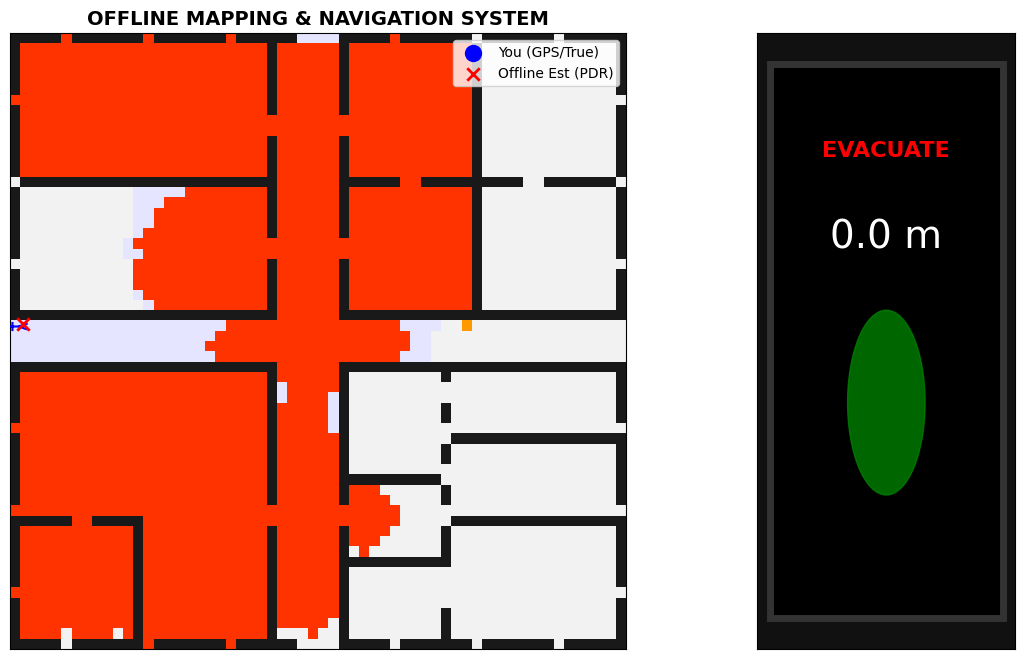

In [50]:
# ==========================================
# VISUALIZATION & MAIN LOOP
# ==========================================

def get_stick_figure_marker(heading_vec):
    dx, dy = heading_vec
    angle = 0
    if dx == 0 and dy == 1: angle = 0 
    elif dx == 0 and dy == -1: angle = 180 
    elif dx == 1 and dy == 0: angle = 270 
    elif dx == -1 and dy == 0: angle = 90
    
    verts = [(0.0, 0.5), (0.0, 0.5), (0.0, -0.2), (-0.3, 0.2), (0.3, 0.2), (0.0, -0.2), (-0.2, -0.8), (0.0, -0.2), (0.2, -0.8)]
    codes = [mpath.Path.MOVETO, mpath.Path.MOVETO, mpath.Path.LINETO, mpath.Path.MOVETO, mpath.Path.LINETO, mpath.Path.MOVETO, mpath.Path.LINETO, mpath.Path.MOVETO, mpath.Path.LINETO]
    return mpath.Path(Affine2D().rotate_deg(angle).transform(verts), codes)

def get_smoothed_instruction(sim, current_node, last_vec):
    # (Simplified Lookahead Logic from previous request)
    return sim.app_instruction # Using direct instruction for robustness in this version

def draw_compass(ax, instruction):
    for p in ax.patches[1:]: p.remove()
    angle_map = {"UP": 90, "DOWN": 270, "LEFT": 180, "RIGHT": 0}
    
    if instruction not in angle_map:
        color = 'green' if instruction == "ESCAPED" else 'red'
        ax.add_patch(mpatches.Circle((0.5, 0.4), 0.15, color=color, alpha=0.8, transform=ax.transAxes))
        return

    angle = angle_map[instruction]
    t = Affine2D().rotate_deg_around(0.5, 0.4, angle) + ax.transAxes
    poly = mpatches.Polygon([(0.5, 0.65), (0.65, 0.30), (0.5, 0.40), (0.35, 0.30)], closed=True, color='#00FFFF', transform=t)
    ax.add_patch(poly)

def run_simulation():
    plt.style.use('default') 
    
    # 1. SETUP MODULES
    layout_mgr = LayoutManager()
    sim = Simulation(size=60, layout_mgr=layout_mgr) # Load offline layout inside init
    feedback_sys = NavigationFeedback()
    pdr = PDRSystem(sim.start_node.x, sim.start_node.y) # Start PDR at same spot
    
    last_move_vector = (0, 1)
    
    # Figure Setup
    fig = plt.figure(figsize=(14, 8))
    gs = fig.add_gridspec(1, 2, width_ratios=[3, 1], wspace=0.1)
    ax = fig.add_subplot(gs[0]); ax_ui = fig.add_subplot(gs[1]) 
    
    # Static Colors
    rgb_grid = [[(0.95,0.95,0.95) for _ in range(sim.size)] for _ in range(sim.size)]
    img_plot = ax.imshow(rgb_grid, origin='lower', interpolation='nearest')
    
    # Dynamic Markers
    agent_body = ax.scatter([], [], marker='o', s=120, color='blue', linewidth=1.5, zorder=10, label='You (GPS/True)')
    pdr_ghost = ax.scatter([], [], marker='x', s=80, color='red', linewidth=2, zorder=11, label='Offline Est (PDR)')
    
    ax.set_xticks([]); ax.set_yticks([]); ax.legend(loc='upper right')
    ax.set_title("OFFLINE MAPPING & NAVIGATION SYSTEM", fontsize=14, fontweight='bold')

    # UI Setup
    ax_ui.set_facecolor('#111111'); ax_ui.set_xticks([]); ax_ui.set_yticks([])
    ax_ui.add_patch(mpatches.Rectangle((0.05, 0.05), 0.9, 0.9, linewidth=5, edgecolor='#333333', facecolor='#000000', transform=ax_ui.transAxes))
    ui_status = ax_ui.text(0.5, 0.80, "STATUS: OK", color='#00FF00', ha='center', fontsize=16, fontweight='bold')
    ui_haptic = ax_ui.text(0.5, 0.05, "", color='yellow', ha='center', fontsize=10) # Haptic Log
    ui_dist = ax_ui.text(0.5, 0.65, "0 m", color='white', ha='center', fontsize=28)
    
    # SIMULATION LOOP
    for _ in range(300):
        prev_node = sim.start_node
        
        # 1. Step Simulation (God Mode)
        sim.step()
        curr_node = sim.start_node
        
        # 2. Update Vector
        dx, dy = curr_node.x - prev_node.x, curr_node.y - prev_node.y
        if (dx, dy) != (0, 0): last_move_vector = (dx, dy)
        
        # 3. RUN OFFLINE MAPPING (PDR)
        # Generate fake sensor data based on the move
        accel, gyro = pdr.simulate_hardware_reading(prev_node, curr_node)
        # Phone calculates position based ONLY on sensor data
        est_x, est_y = pdr.update_estimate(accel, gyro)
        
        # 4. FEEDBACK TRIGGER
        inst = sim.app_instruction
        haptic_msg = feedback_sys.trigger(inst)
        if haptic_msg: ui_haptic.set_text(haptic_msg)

        # 5. DRAWING
        # Update Map Colors
        for n in sim.nodes_list:
            col = (0.95, 0.95, 0.95)
            if n.type == 'WALL': col = (0.1, 0.1, 0.1)
            elif n.type == 'FIRE': col = (1.0, 0.2, 0.0)
            elif n.type == 'CROWD': col = (1.0, 0.6, 0.0)
            elif n.visited: col = (0.9, 0.9, 1.0) # Blue tint for explored areas
            
            rgb_grid[n.y][n.x] = col

        img_plot.set_data(rgb_grid)
        
        # Update Agents
        agent_body.set_paths([get_stick_figure_marker(last_move_vector)])
        agent_body.set_offsets([[curr_node.x, curr_node.y]])
        
        # Draw Ghost (Where the phone thinks you are)
        pdr_ghost.set_offsets([[est_x, est_y]])

        # Update UI
        ui_dist.set_text(f"{sim.dist_to_exit:.1f} m")
        draw_compass(ax_ui, inst)
        
        if sim.panic_mode: 
            ui_status.set_text("EVACUATE"); ui_status.set_color('red')
        
        display(fig)
        clear_output(wait=True)
        time.sleep(DELAY_BETWEEN_FRAMES)

        if sim.escaped or sim.trapped:
            break

    print(f"Result: {'Escaped' if sim.escaped else 'Trapped'}")

if __name__ == "__main__":
    run_simulation()